In [1473]:
import numpy as np
from scipy.signal import convolve2d, correlate2d
import matplotlib.pyplot as plt
import sys
sys.path.append("..")
from Functions.Functions import *
import time

In [1468]:
def gaussfft(pic, t):
    
    ## Gaussian kernel
    Nx, Ny = pic.shape
    x = np.arange(0, Ny)
    y = np.arange(0, Nx)
    X, Y = np.meshgrid(x, y)
    X = X - Ny/2
    Y = Y - Nx/2

    gaussian_kernel = np.exp(-(X**2 + Y**2)/(2*t))
    gaussian_kernel /= np.sum(gaussian_kernel)

    ## Move origin of filter to corner (0,0)
    gaussian_kernel = np.fft.ifftshift(gaussian_kernel)

    ## Compute convolution
    F = fft2(pic)
    FG = fft2(gaussian_kernel)
    return np.real(ifft2(F * FG)) 

In [1559]:
def create_plots(rows, cols, image_list, row_list=None, col_list=None,
                 figsize_per_image=(3, 3), title_fontsize=15, label_fontsize=15):
    """
    Display images in a grid with optional row and column titles.
    Column titles are placed on the top row (via set_title).
    Row titles are added as rotated figure text on the left.
    """

    fig, axes = plt.subplots(rows, cols, figsize=(cols * figsize_per_image[0],
                                                  rows * figsize_per_image[1]))
    axes = np.atleast_2d(axes)

    img_idx = 0
    for r in range(rows):
        for c in range(cols):
            ax = axes[r, c]
            plt.sca(ax)

            if img_idx >= len(image_list):
                ax.axis("off")
                continue

            showgrey(image_list[img_idx], display=False)
            ax.axis("off") 

            # Column titles
            if col_list and r == 0 and c < len(col_list):
                ax.set_title(col_list[c], fontsize=title_fontsize)

            img_idx += 1

    # Add row labels as rotated figure text
    if row_list:
        fig.tight_layout()  # ensure positions are up-to-date before reading bbox
        fig.canvas.draw()   # necessary to get correct positions in some backends

        # Find the leftmost x position of the first column
        left_edge = min(ax.get_position().x0 for ax in axes[:, 0])
        x_text = left_edge - 0.02  # small offset to the left

        for r, label in enumerate(row_list[:rows]):
            ax0 = axes[r, 0]
            bbox = ax0.get_position()
            ycenter = (bbox.y0 + bbox.y1) / 2
            plt.figtext(x_text, ycenter, label, fontsize=label_fontsize,
                        va='center', ha='center', rotation=90)
    else:
        plt.tight_layout()

    plt.show()

## 1. Difference operators

In [1560]:
# central differences
def deltax(im, h=1):
    diff = []
    for i in range((im.shape[0])-h):
        diff_i = (im[i + h, :] - im[i - h, :]) / 2 * h
        diff.append(diff_i)
    
    return np.array(diff)
    # diff = (im_x[h:] - im_x[:-h]) /= 2 * h

In [ ]:
def deltay(im, h=1):
    diff = []
    for i in range(im.shape[1]-h):
        diff_i = (im[:, i + h] - im[:, i - h]) / 2 * h
        diff.append(diff_i)

    return np.array(diff)

In [1562]:
tools = np.load("../DD2423_Python_Labs_1_2/Images-npy/few256.npy")

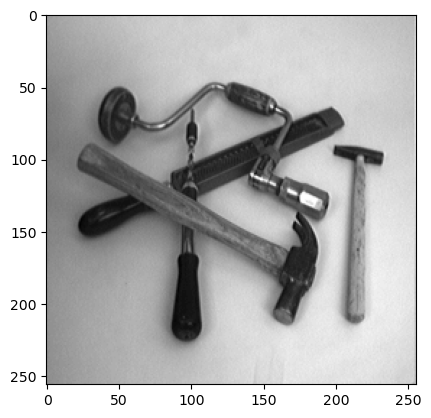

In [1563]:
showgrey(tools)

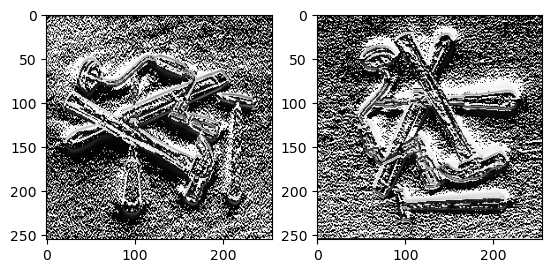

In [1564]:
plt.subplot(1, 2, 1)
diff_x_tools = deltax(tools, h=1)
showgrey(diff_x_tools, display=False)

plt.subplot(1, 2, 2)
diff_y_tools = deltay(tools, h=1)
showgrey(diff_y_tools, display=False)

In [1566]:
# for h=1
dxmask = np.zeros((3, 3))
dxmask[1, 0] = 0.5
dxmask[1, 2] = -0.5
print(dxmask)

dymask = np.zeros((3, 3))
dymask[0, 1] = 0.5
dymask[2, 1] = -0.5
print(dymask)

[[ 0.   0.   0. ]
 [ 0.5  0.  -0.5]
 [ 0.   0.   0. ]]
[[ 0.   0.5  0. ]
 [ 0.   0.   0. ]
 [ 0.  -0.5  0. ]]


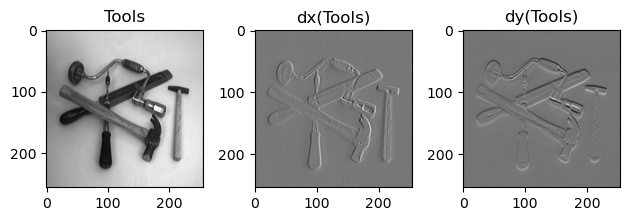

In [1572]:
plt.subplot(1, 3, 1)
showgrey(tools, display=False)
plt.title("Tools")

dxtools = convolve2d(tools, dxmask, 'valid')
dytools = convolve2d(tools, dymask, 'valid')

plt.subplot(1, 3, 2)
showgrey(dxtools, display=False)
plt.title("dx(Tools)")

plt.subplot(1, 3, 3)
showgrey(dytools, display=False)
plt.title("dy(Tools)")

plt.tight_layout()
plt.show()

dx: accentuates edges that are strong along rows (horizontally), i.e. "vertical edges"

dy: accentuates edges that are strong along columns (vertically), i.e. "horisontal edges"

In [ ]:
print("Tools shape: ", tools.shape)
print("Dxtools shape ", dxtools.shape)   # we lose first and last pixel

Tools shape:  (256, 256)
Dxtools shape  (254, 254)


## 2. Point–wise thresholding of gradient magnitudes

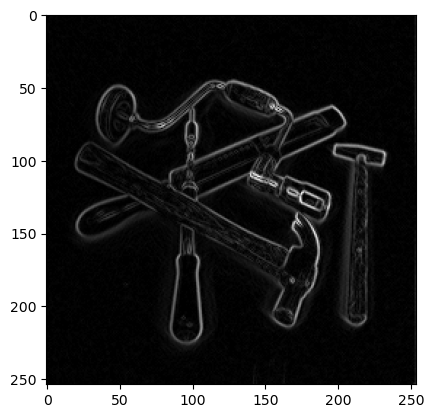

In [1573]:
gradmagntools = np.sqrt(dxtools**2 + dytools**2)
showgrey(gradmagntools, display=True)

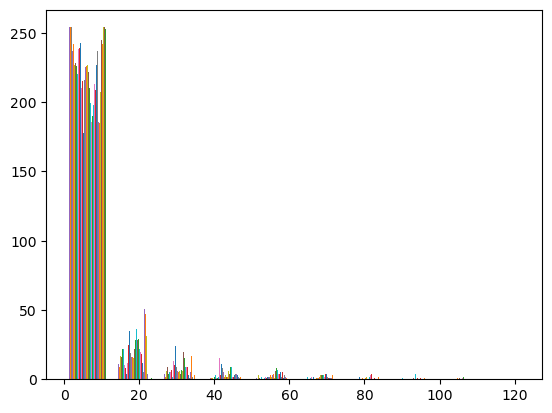

In [1574]:
# Compute the histogram of this image (using numpy.histogram()) and use this to guess a threshold that yields reasonably thin edges when applied to gradmagntools

# y-axis: pixels
# x-axel: magnitude
# i.e. how many pixels have a high magnitude (large change)? Not so many have higher than 10-15
np.histogram(gradmagntools)
hist1 = plt.hist(gradmagntools)

(array([[114.,  45.,  44., ...,   1.,   0.,   0.],
        [110.,  47.,  37., ...,   1.,   0.,   0.],
        [ 94.,  39.,  48., ...,   0.,   0.,   0.],
        ...,
        [204.,  40.,   6., ...,   0.,   0.,   0.],
        [212.,  31.,   6., ...,   0.,   0.,   0.],
        [ 27.,  33.,  65., ...,   1.,   0.,   0.]], shape=(254, 10)),
 array([  0.        ,  13.39972015,  26.79944029,  40.19916044,
         53.59888059,  66.99860073,  80.39832088,  93.79804102,
        107.19776117, 120.59748132, 133.99720146]),
 <a list of 254 BarContainer objects>)

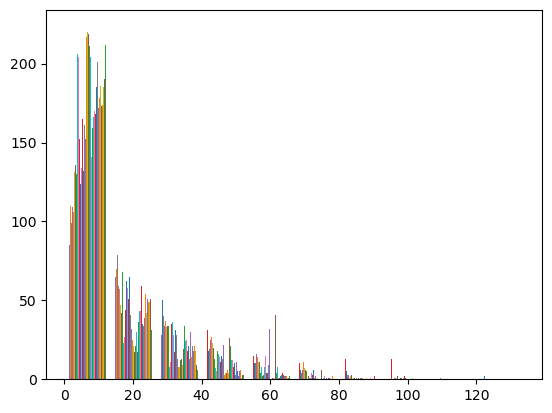

In [1576]:
godthem = np.load("../DD2423_Python_Labs_1_2/Images-npy/godthem256.npy")
dxgodthem = convolve2d(godthem, dxmask, 'valid')
dygodthem = convolve2d(godthem, dymask, 'valid')

gradmagngodthem = np.sqrt(dxgodthem**2 + dygodthem**2)
plt.hist(gradmagngodthem)

After convolution, we have a more spread out magnitude histogram and take some of the highest magnitudes to accentuate edges without the precense of noise. Fewer pixels have the highest magnitude, because we removed that noise.

In [1467]:
def Lv(inpic, dxmask, dymask, shape = 'same', sigma=None):   # sigma = None if we send in an already smoothed image
    if sigma is not None:
        inpic = gaussfft(inpic, sigma)
    Lx = convolve2d(inpic, dxmask, shape)
    Ly = convolve2d(inpic, dymask, shape)
    return np.sqrt(Lx**2 + Ly**2)

(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)


Text(0.5, 1.0, 'Magnitude with smoothing')

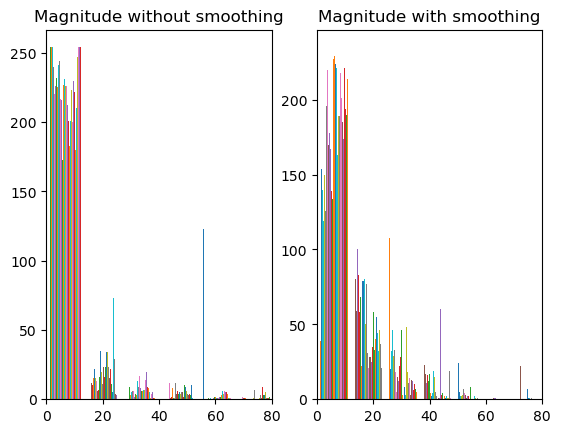

In [1577]:
blurred_godthem = discgaussfft(tools, 1)
blurred_tools = discgaussfft(godthem, 1)

plt.subplot(1,2,1)
plt.hist(Lv(tools, dxmask, dymask))
plt.xlim(0,80)     # zooming in on x axis to see better
plt.title("Magnitude without smoothing")

plt.subplot(1,2,2)
plt.hist(Lv(blurred_tools, dxmask, dymask))
plt.xlim(0,80)     # zooming in on x axis to see better
plt.title("Magnitude with smoothing")

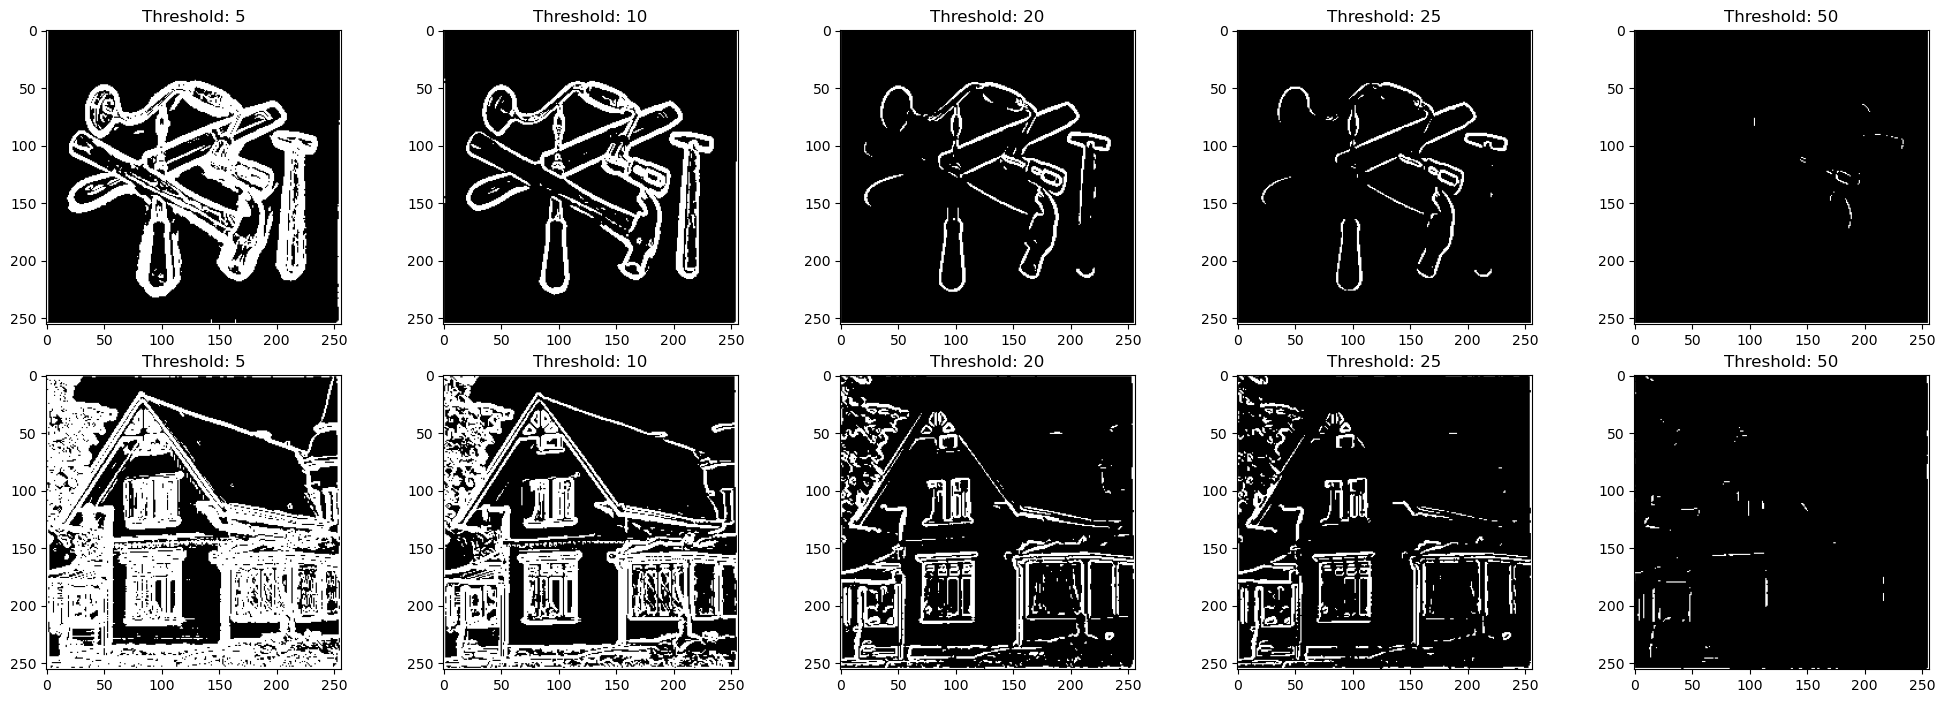

In [ ]:
# reasonably thin edges: tradeoff between connected and thin edges, where we get thinner edge for higher threshold

gradmagngodthem = Lv(blurred_godthem, dxmask, dymask)
gradmagntools = Lv(blurred_tools, dxmask, dymask)

thresholds = [5, 10, 20, 25, 50]
plt.figure(figsize=(20,15))
for i, threshold in enumerate(thresholds):
    plt.subplot(1, 5, i+1)
    plt.title(f"Threshold: {threshold}")
    showgrey((gradmagntools > threshold).astype(int), display=False)
    
    plt.subplot(2, 5, i+1)
    plt.title(f"Threshold: {threshold}")
    showgrey((gradmagngodthem > threshold).astype(int), display=False)
    

plt.tight_layout() 
plt.show()

In [149]:
# we have the dxmask and dymask already, but we pad it to be 5x5
print(dxmask)
print("\n")

print(dymask)
print("\n")

dxmask_5_5 = np.pad(dxmask.copy(), pad_width=(1, 1), mode='constant')
print(dxmask_5_5)

dymask_5_5 = np.pad(dymask.copy(), pad_width=(1, 1), mode='constant')
print(dymask_5_5)


[[ 0.   0.   0. ]
 [ 0.5  0.  -0.5]
 [ 0.   0.   0. ]]


[[ 0.   0.5  0. ]
 [ 0.   0.   0. ]
 [ 0.  -0.5  0. ]]


[[ 0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0. ]
 [ 0.   0.5  0.  -0.5  0. ]
 [ 0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0. ]]
[[ 0.   0.   0.   0.   0. ]
 [ 0.   0.   0.5  0.   0. ]
 [ 0.   0.   0.   0.   0. ]
 [ 0.   0.  -0.5  0.   0. ]
 [ 0.   0.   0.   0.   0. ]]


In [150]:
dxxmask = np.zeros((3, 3))

dxxmask[1, 0] = 1
dxxmask[1, 1] = -2
dxxmask[1, 2] = 1

print(dxxmask)
print("\n")

dyymask = dxxmask.transpose()
print(dyymask)

[[ 0.  0.  0.]
 [ 1. -2.  1.]
 [ 0.  0.  0.]]


[[ 0.  1.  0.]
 [ 0. -2.  0.]
 [ 0.  1.  0.]]


In [138]:
dxxmask_5_5 = np.zeros((5, 5))

dxxmask_5_5[2, 1] = 1
dxxmask_5_5[2, 2] = -2
dxxmask_5_5[2, 3] = 1

print(dxxmask_5_5)
print("\n")

dyymask_5_5 = dxxmask_5_5.transpose()
print(dyymask_5_5)


[[ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  1. -2.  1.  0.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]]


[[ 0.  0.  0.  0.  0.]
 [ 0.  0.  1.  0.  0.]
 [ 0.  0. -2.  0.  0.]
 [ 0.  0.  1.  0.  0.]
 [ 0.  0.  0.  0.  0.]]


## 4 Computing differential geometry descriptors

In [1469]:
def Lvvtilde(L, shape = 'same', sigma=None, kernel_size=5):
    if sigma is not None:
        L = gaussfft(L, sigma)
    else:
        L = L.copy()      # L is a gaussian blurred image
    
    Lx = convolve2d(L, dxmask_5_5, shape)
    Ly = convolve2d(L, dymask_5_5, shape)
    
    dxxmask = convolve2d(dxmask_5_5, dxmask_5_5, shape)
    dyymask = convolve2d(dymask_5_5, dymask_5_5, shape)
    dxymask = convolve2d(dxmask_5_5, dymask_5_5, shape)
    
    Lxx = convolve2d(L, dxxmask, shape)
    Lyy = convolve2d(L, dyymask, shape)
    Lxy = convolve2d(L, dxymask, shape)
    
    Lvvtilde = Lx ** 2 * Lxx + 2 * Lx * Ly * Lxy + Ly ** 2 * Lyy
    return Lvvtilde

In [281]:
print(dxmask_5_5)
print(dymask_5_5)

print(dxmask)
print(dymask)

[[ 0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0. ]
 [ 0.   0.5  0.  -0.5  0. ]
 [ 0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0. ]]
[[ 0.   0.   0.   0.   0. ]
 [ 0.   0.   0.5  0.   0. ]
 [ 0.   0.   0.   0.   0. ]
 [ 0.   0.  -0.5  0.   0. ]
 [ 0.   0.   0.   0.   0. ]]
[[ 0.   0.   0. ]
 [ 0.5  0.  -0.5]
 [ 0.   0.   0. ]]
[[ 0.   0.5  0. ]
 [ 0.   0.   0. ]
 [ 0.  -0.5  0. ]]


In [1470]:
def Lvvvtilde(L, shape = 'same', sigma=None, kernel_size=5):
    if sigma is not None:
        L = gaussfft(L, sigma)
    else:
        L = L.copy()   # if image is smoothed beforehand
        
    Lx = convolve2d(L, dxmask_5_5, shape)
    Ly = convolve2d(L, dymask_5_5, shape)
    
    dxxmask = convolve2d(dxmask_5_5, dxmask_5_5, shape)
    dyymask = convolve2d(dymask_5_5, dymask_5_5, shape)
    dxymask = convolve2d(dxmask_5_5, dymask_5_5, shape)
    
    Lxx = convolve2d(L, dxxmask, shape)
    Lyy = convolve2d(L, dyymask, shape)
    Lxy = convolve2d(L, dxymask, shape)
    
    dxxxmask = convolve2d(dxmask_5_5, dxxmask, shape)
    dyyymask = convolve2d(dymask_5_5, dyymask, shape)
    dxxymask = convolve2d(dxmask_5_5, dxymask, shape)
    dxyymask = convolve2d(dxymask, dymask_5_5, shape)
    
    Lxxx = convolve2d(L, dxxxmask, shape)
    Lyyy = convolve2d(L, dyyymask, shape)
    Lxxy = convolve2d(L, dxxymask, shape)
    Lxyy =convolve2d(L, dxyymask, shape)
    
    Lvvvtilde = (Lx ** 3) * Lxxx + 3 * ((Lx **2) * Ly * Lxxy) + 3 * (Lx * (Ly **2) * Lxyy) + (Ly**3) * Lyyy
    
    return Lvvvtilde

In [154]:
# Reference data
[x, y] = np.meshgrid(range(-5, 6), range(-5, 6))
dxxxmask = convolve2d(dxmask, dxxmask, 'same')
dyyymask = convolve2d(dymask, dyymask, 'same')
dxxymask = convolve2d(dxxmask, dymask, 'same')

print(convolve2d(x**3, dxxxmask, 'valid'))
print(convolve2d(x**3, dxxmask, 'valid'))
print(convolve2d(x**2*y, dxxymask, 'valid'))

[[-98. -56. -26.  -8.  -2.  -8. -26. -56. -98.]
 [-98. -56. -26.  -8.  -2.  -8. -26. -56. -98.]
 [-98. -56. -26.  -8.  -2.  -8. -26. -56. -98.]
 [-98. -56. -26.  -8.  -2.  -8. -26. -56. -98.]
 [-98. -56. -26.  -8.  -2.  -8. -26. -56. -98.]
 [-98. -56. -26.  -8.  -2.  -8. -26. -56. -98.]
 [-98. -56. -26.  -8.  -2.  -8. -26. -56. -98.]
 [-98. -56. -26.  -8.  -2.  -8. -26. -56. -98.]
 [-98. -56. -26.  -8.  -2.  -8. -26. -56. -98.]]
[[-24. -18. -12.  -6.   0.   6.  12.  18.  24.]
 [-24. -18. -12.  -6.   0.   6.  12.  18.  24.]
 [-24. -18. -12.  -6.   0.   6.  12.  18.  24.]
 [-24. -18. -12.  -6.   0.   6.  12.  18.  24.]
 [-24. -18. -12.  -6.   0.   6.  12.  18.  24.]
 [-24. -18. -12.  -6.   0.   6.  12.  18.  24.]
 [-24. -18. -12.  -6.   0.   6.  12.  18.  24.]
 [-24. -18. -12.  -6.   0.   6.  12.  18.  24.]
 [-24. -18. -12.  -6.   0.   6.  12.  18.  24.]]
[[2. 2. 2. 2. 2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 

In [ ]:
# Reference data
[x, y] = np.meshgrid(range(-5, 6), range(-5, 6))
dxxxmask = convolve2d(dxmask_5_5, dxxmask, 'same')
dyyymask = convolve2d(dymask_5_5, dyymask, 'same')
dxxymask = convolve2d(dxxmask_5_5, dymask, 'same')

print(convolve2d(x**3, dxxxmask, 'valid'))
print(convolve2d(x**3, dxxmask, 'valid'))
print(convolve2d(x**2*y, dxxymask, 'valid'))

[[6. 6. 6. 6. 6. 6. 6.]
 [6. 6. 6. 6. 6. 6. 6.]
 [6. 6. 6. 6. 6. 6. 6.]
 [6. 6. 6. 6. 6. 6. 6.]
 [6. 6. 6. 6. 6. 6. 6.]
 [6. 6. 6. 6. 6. 6. 6.]
 [6. 6. 6. 6. 6. 6. 6.]]
[[-24. -18. -12.  -6.   0.   6.  12.  18.  24.]
 [-24. -18. -12.  -6.   0.   6.  12.  18.  24.]
 [-24. -18. -12.  -6.   0.   6.  12.  18.  24.]
 [-24. -18. -12.  -6.   0.   6.  12.  18.  24.]
 [-24. -18. -12.  -6.   0.   6.  12.  18.  24.]
 [-24. -18. -12.  -6.   0.   6.  12.  18.  24.]
 [-24. -18. -12.  -6.   0.   6.  12.  18.  24.]
 [-24. -18. -12.  -6.   0.   6.  12.  18.  24.]
 [-24. -18. -12.  -6.   0.   6.  12.  18.  24.]]
[[2. 2. 2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2. 2. 2.]]


In [165]:
f = x**3
df = convolve2d(f, dxmask, mode='valid')
df_5_5 = convolve2d(f, dxmask_5_5, mode='valid')
print(f.shape)
print(df.shape)
print(df_5_5.shape)

(11, 11)
(9, 9)
(7, 7)


In [ ]:
def test_property_1(dxmask):
    for n in [1, 2, 3, 4]:
        f = x**n
        df = convolve2d(f, dxmask, mode='valid')
        
        # Expected leading term: n*x^(n-1)
        expected = n * x**(n-1)
        expected = expected[2:-2, 2:-2]   # because convolution shrunk the image by two pixels on each side
        # expected = expected[1:-1, 1:-1]
        
        err = df - expected
        print(f"n={n}: max(abs(error)) =", np.max(np.abs(err)))

In [ ]:
def test_property_2(dxmask, dxxmask, dxxxmask, n = 3):
    # n = 2
   
    f = x**n
    if n==1:
        result = convolve2d(f, dxmask, mode='valid')
    
    elif n==2:
        result = convolve2d(f, dxxmask, mode='valid')
        
    elif n==3:
        result = convolve2d(f, dxxxmask, mode='valid')
    
    # Expected leading term: n*x^(n-1)
    expected = math.factorial(n)
    
    err = result - expected
    print(f"n={n}: max(abs(error)) =", np.max(np.abs(err)))

In [1440]:
def dx_mask(h=1, pad = 5):
    dx = np.zeros((pad, pad))
    f = np.array([1,0,-1])/(2*h)
    f = np.pad(f, 0 if pad == 3 else 1)
    dx[pad//2 ,:] = f
    return dx

def dy_mask(h=1, pad = 5):
    return dx_mask(h=h, pad = pad).T

def dxx_mask(h=1, pad = 5):
    dxx = np.zeros((pad, pad))
    f = np.array([1, -2, 1])/(h**2)
    f = np.pad(f, 0 if pad == 3 else 1)
    dxx[pad //2 ,:] = f
    return dxx

def dyy_mask(h=1, pad = 5):
    return dxx_mask(h=h, pad = pad).T

In [1441]:
def d_filters(pad=5, order=3):
    dx = dx_mask(1, pad)
    dy = dy_mask(1, pad)

    dxx, dyy, dxy, dxxy, dxyy, dxxx, dyyy = [None] * 7

    if order >= 2:
        dxx = dxx_mask(1, pad)
        dyy = dyy_mask(1, pad)
        dxy = convolve2d(dx, dy, 'same')
    
    
    if order >= 3:
        dxxx = convolve2d(dx, dxx, 'same')
        dyyy = convolve2d(dy, dyy, 'same')
        dxxy = convolve2d(dxx, dy, 'same')
        dxyy = convolve2d(dx, dyy, 'same')
    
    return dx, dy, dxx, dyy, dxy, dxxy, dxyy, dxxx, dyyy

In [ ]:
# All tests for section 4)
def test1(var, n, pad=5):
    '''
    # Test 1: dx(x^n) = nx^(n-1)

    var: 2d variable (x or y)
    u: axis to derivate
    n: order of derivate
    '''
    f = var ** n
    dx, dy, dxx, dyy, dxy, dxxy, dxyy, dxxx, dyyy = d_filters(pad=pad)

    u_num = convolve2d(f, dx, 'valid')
    u_analytic = n * var**(n-1)

    #return u_num, u_analytic
    assert np.allclose(u_num, u_analytic, 1e-6), "Test not passed!"

def test2(var, n, pad=5):
    '''
    # Test 2: dx^n(x^n) = n!

    var: 2d variable (x or y)
    u: axis to derivate
    n: order of derivate
    '''
    f = var ** n
    dx, dy, dxx, dyy, dxy, dxxy, dxyy, dxxx, dyyy = d_filters(pad=pad)

    if n == 1:
        dd = dx
    elif n == 2: 
        dd = dxx
    elif n == 3:
        dd = dxxx

    u_num = convolve2d(f, dd, 'valid')
    u_analytic = math.factorial(n) * np.ones(shape=u_num.shape)

    assert np.allclose(u_num, u_analytic, 1e-6), "Test not passed!"

def test3(var, n, pad=5):
    '''
     # Test 3: dx^(n+k)(x^n) = 0

    var: 2d variable (x or y)
    u: axis to derivate
    n: order of derivate
    '''
    f = var ** n
    dx, dy, dxx, dyy, dxy, dxxy, dxyy, dxxx, dyyy = d_filters(pad=pad)

    if n == 1:
        dd = dxx
    elif n == 2: 
        dd = dxxx
    u_num = convolve2d(f, dd, 'valid')
    
    assert np.allclose(u_num, np.zeros(shape=u_num.shape)), "Test not passed!"

def test4(var, n, pad=5, axis='x'):
    '''
     # Test 4: dx^n(y^k) = 0

    var: 2d variable (x or y)
    u: axis to derivate
    n: order of derivate
    '''
    f = var ** n
    dx, dy, dxx, dyy, dxy, dxxy, dxyy, dxxx, dyyy = d_filters(pad=pad)
    if axis == 'y':
        if n == 1:
            dd = dx
        elif n == 2: 
            dd = dxx
        elif n == 3:
            dd = dxxx
    elif axis == 'x':
        if n == 1:
            dd = dy
        elif n == 2: 
            dd = dyy
        elif n == 3:
            dd = dyyy
    
    u_num = convolve2d(f, dd, 'valid')
    assert np.allclose(u_num, np.zeros(shape=u_num.shape)), "Test not passed!"

[x, y] = np.meshgrid(range(-5, 6), range(-5, 6))

test2(x, n=1)
test2(x, n=2)
test2(x, n=3)

test3(x, n=1)
test3(x, n=2)

test4(x, n=1, axis='x')
test4(x, n=2, axis='x')
test4(x, n=3, axis='x')
test4(y, n=1, axis='y')
test4(y, n=2, axis='y')
test4(y, n=3, axis='y')


In [1443]:
def tests(x, y):
    dx, dy, dxx, dyy, dxy, dxxy, dxyy, dxxx, dyyy = d_filters(pad=5)
    f1 = convolve2d(x**3, dxxx, 'valid')
    assert np.allclose(f1, 6*np.ones(shape=f1.shape)), "Test not passed!"

    f2 = convolve2d(x**3, dxx, 'valid')
    analytical = 6*x

    extra_cols = len(analytical) - len(f2)
    analytical = analytical[extra_cols//2:extra_cols//2 + len(f2), extra_cols//2:extra_cols//2 + len(f2)]

    assert np.allclose(f2, analytical), "Test not passed!"

    f3 = convolve2d(x**2*y, dxxy, 'valid')
    assert np.allclose(f3, 2*np.ones(shape=f3.shape)), "Test not passed!"

[x, y] = np.meshgrid(range(-5, 6), range(-5, 6))
tests(x, y)

In [179]:
print(dxmask)

[[ 0.   0.   0. ]
 [ 0.5  0.  -0.5]
 [ 0.   0.   0. ]]


In [180]:
test_property_2(dxmask_5_5, dxxmask_5_5, dxxxmask, n=1)
test_property_2(dxmask_5_5, dxxmask_5_5, dxxxmask, n=2)
test_property_2(dxmask_5_5, dxxmask_5_5, dxxxmask, n=3)

n=1: max(abs(error)) = 0.0
n=2: max(abs(error)) = 0.0
n=3: max(abs(error)) = 0.0


In [167]:
test_property_1(dxmask_5_5)

n=1: max(abs(error)) = 0.0
n=2: max(abs(error)) = 0.0
n=3: max(abs(error)) = 1.0
n=4: max(abs(error)) = 12.0


In [169]:
test_property_1(dxmask)

n=1: max(abs(error)) = 0.0
n=2: max(abs(error)) = 0.0
n=3: max(abs(error)) = 1.0
n=4: max(abs(error)) = 16.0


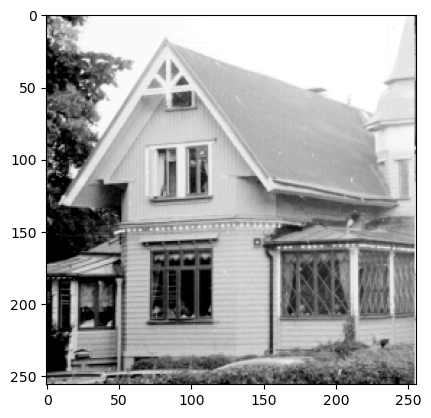

In [249]:
house = np.load("../DD2423_Python_Labs_1_2/Images-npy/godthem256.npy")
# showgrey(discgaussfft(house, 64))

showgrey(house)
# showgrey(convolve2d(house, dxxmask, "same"), 1)

(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)


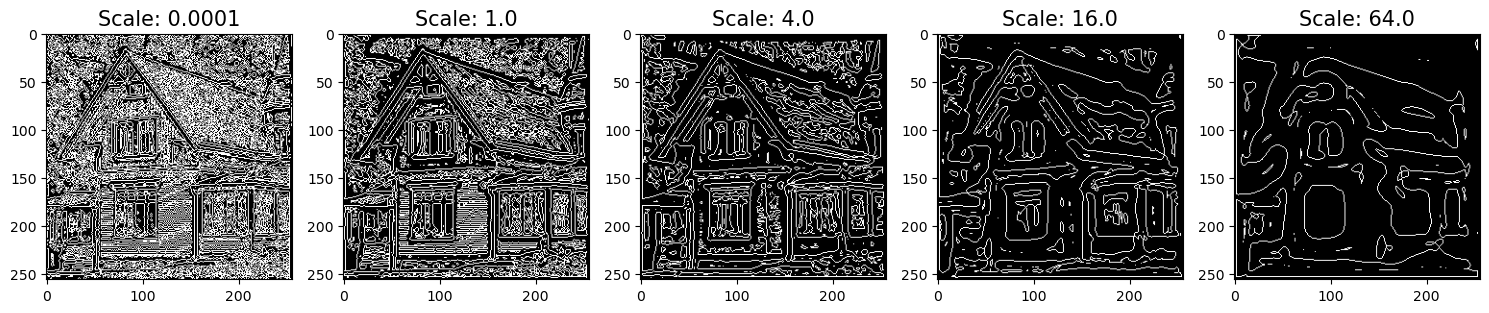

In [225]:
scales = [0.0001, 1.0, 4.0, 16.0, 64.0]
house = np.load("../DD2423_Python_Labs_1_2/Images-npy/godthem256.npy")
im_list = []
titles = []

for i, scale in enumerate(scales):  
    im_list.append(contour(Lvvtilde(discgaussfft(house, scale), 'same')))
    titles.append(f"Scale: {scale}")

create_plots(1, 5, im_list, row_list=None, col_list=titles,figsize_per_image=(3, 3), title_fontsize=15, label_fontsize=15)

In [1580]:
def detect_edges(img, sigma, threshold=None, kernel_size=5, out='curves', return_gradmagn=False):
    dx, dy, *_ = d_filters(pad=5)
    
    Lv_magnitude = Lv(img, dx, dy, shape = 'same', sigma=sigma)
    Lvv = Lvvtilde(img, sigma=sigma, kernel_size=kernel_size)
    if out == 'Lvvmask':
        return Lvv

    Lvvv = Lvvvtilde(img, sigma=sigma, kernel_size=kernel_size)
    mask1 = Lvvv < 0
    if out == 'Lvvvmask':
        return mask1
    
    if out == 'curves':
        curves = zerocrosscurves(Lvv, mask1)
        
        if threshold is not None:
            mask2 = Lv_magnitude > threshold
            curves = thresholdcurves(curves, mask2)
        if return_gradmagn:
            return curves, Lv_magnitude
        else:
            return curves
    

(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)


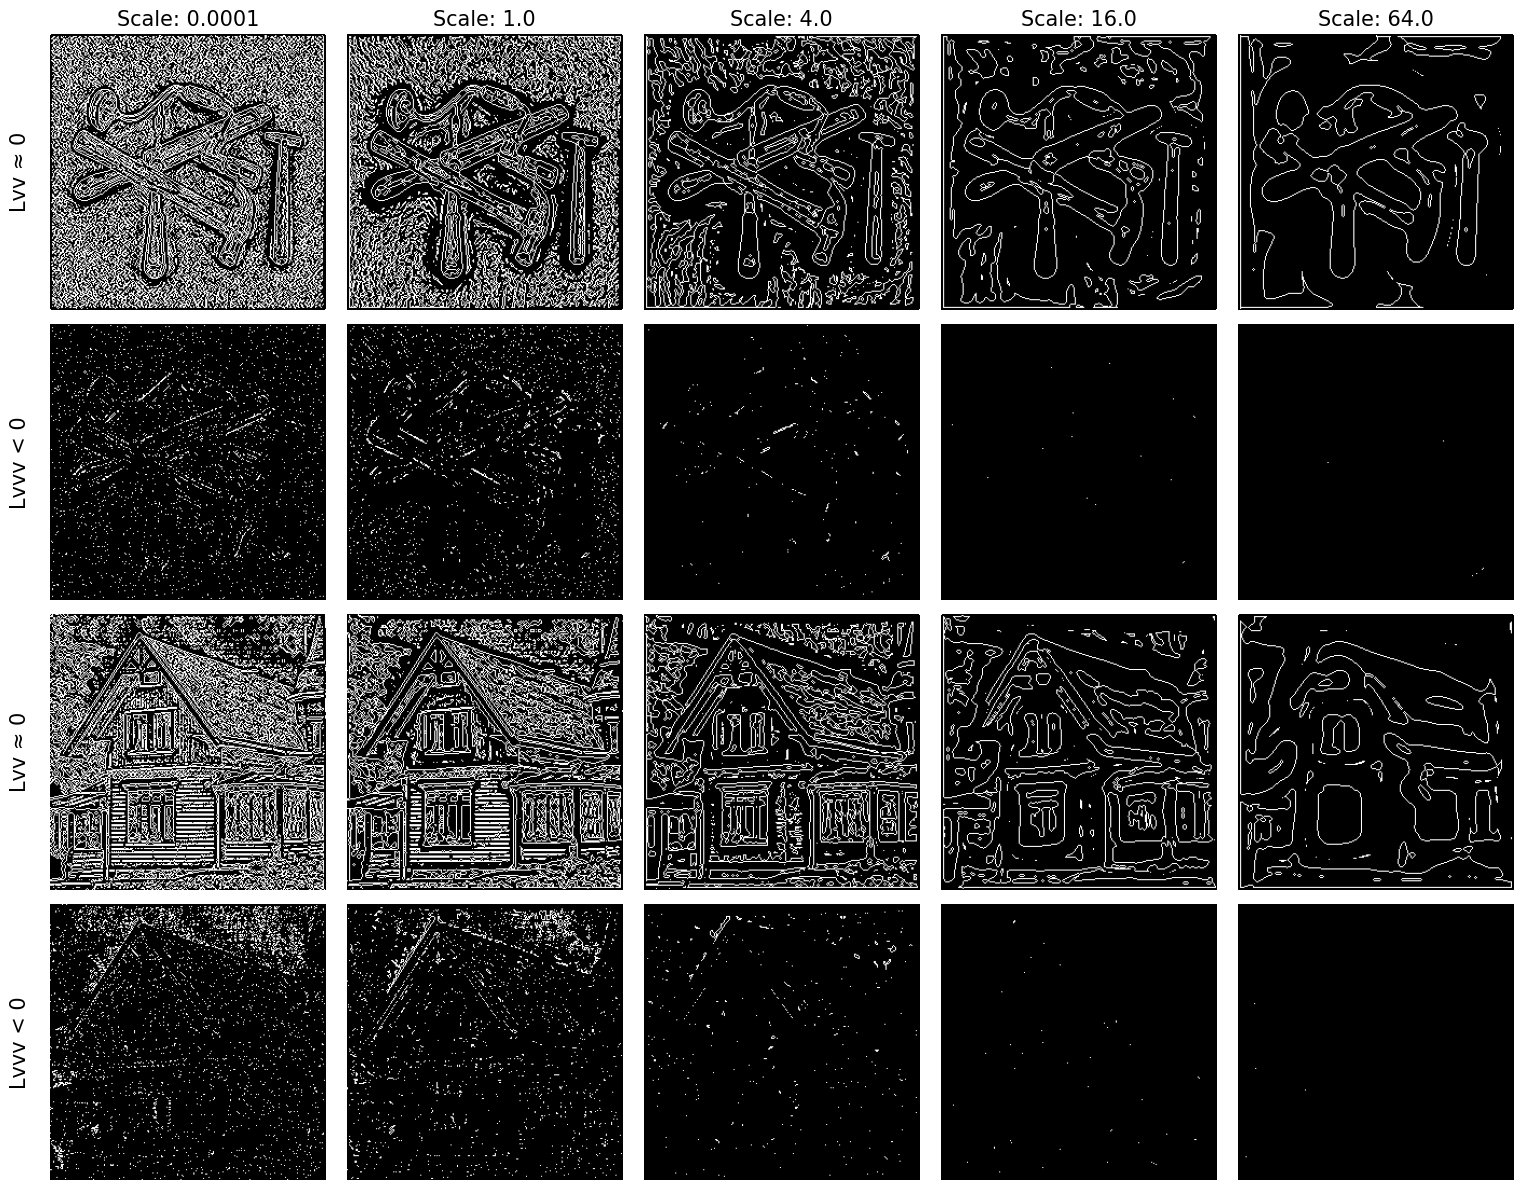

In [1579]:
# Question 6:
scales = [0.0001, 1.0, 4.0, 16.0, 64.0]
tools = np.load("../DD2423_Python_Labs_1_2/Images-npy/few256.npy")
im_list = []
col_titles = []
row_titles = []
Lvv_images_tools = []
Lvvv_images_tools = []
Lvv_images_house = []
Lvvv_images_house = []

for i, scale in enumerate(scales):  
    row_titles.append(f"Lvv ≈ 0")
    Lvv_images_house.append(contour(Lvvtilde(discgaussfft(house, scale), 'same')<1e-10).astype(int))
    
    row_titles.append(f"Lvvv < 0")
    Lvvv_images_house.append(contour(Lvvvtilde(discgaussfft(house, scale), 'same')<0).astype(int))
    
    row_titles.append(f"Lvv ≈ 0")
    
    Lvv_images_tools.append(contour(Lvvtilde(discgaussfft(tools, scale), 'same')<1e-10).astype(int))   # almost 0
    
    row_titles.append(f"Lvvv < 0")
    Lvvv_images_tools.append(contour(Lvvvtilde(discgaussfft(tools, scale), 'same')<0).astype(int))
    
    col_titles.append(f"Scale: {scale}")

im_list = Lvv_images_tools + Lvvv_images_tools + Lvv_images_house + Lvvv_images_house
create_plots(4, 5, im_list, row_list=row_titles, col_list=col_titles,figsize_per_image=(3, 3), title_fontsize=15, label_fontsize=15)

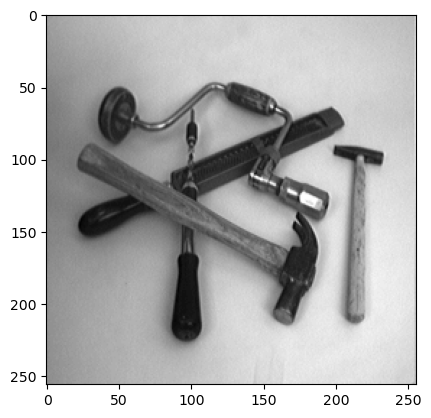

In [260]:
showgrey(tools)

## 5. Extraction of edge segments


(256, 256) (256, 256) (256, 256)


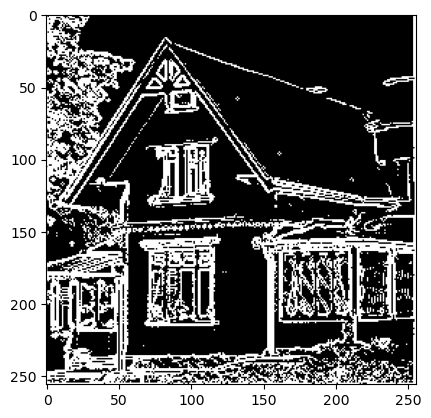

[[ True  True  True ...  True  True  True]
 [ True False  True ... False  True  True]
 [ True  True  True ... False  True  True]
 ...
 [ True False False ...  True  True  True]
 [ True  True  True ... False  True  True]
 [ True  True  True ...  True  True  True]]


In [1584]:
def extractedge(inpic, scale, threshold=None, shape='same'):
    L = discgaussfft(inpic, scale)
    L_magn = Lv(L, dxmask, dymask)
    Lvv = Lvvtilde(L, shape)
    Lvvv = Lvvvtilde(L, shape)
    
    if threshold != None:
        # edge_mask = (np.abs(Lvv)<1e-10).astype(int) & (Lvvv<0).astype(int) & (L_magn > threshold).astype(int)
        edge_mask = (Lvvv<0) & (L_magn > threshold)
        
    else: 
        edge_mask = (Lvvv<0)
        # edge_mask = (np.abs(Lvv)<1e-10).astype(int)
    
    return edge_mask
    

edge_mask = extractedge(house, scale=0.0001, threshold=20)
showgrey(edge_mask.astype(int))

print(edge_mask)

(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)


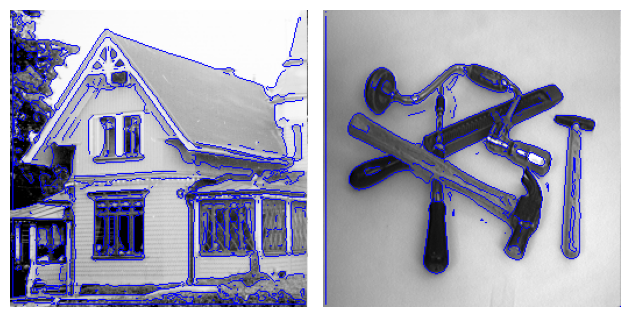

In [ ]:
plt.subplot(1, 2, 1)
mask1 = extractedge(house, scale=4, threshold=None)
mask2 = extractedge(house, scale=4, threshold=3)    

threshold = 15
L = discgaussfft(house, 4)
L_magn = Lv(L, dxmask, dymask)
Lvv = Lvvtilde(L, 'same')
Lvvv = Lvvvtilde(L, 'same')
# zeropic = np.abs(Lvv)<1e-10
zeropic = Lvv

curves = zerocrosscurves(zeropic, mask1)
curves = thresholdcurves(curves, mask2)

overlaycurves(house, curves)

plt.subplot(1, 2, 2)

mask1 = extractedge(tools, scale=4, threshold=None)
mask2 = extractedge(tools, scale=4, threshold=3)    

threshold = 15
L = discgaussfft(tools, 4)
L_magn = Lv(L, dxmask, dymask)
Lvv = Lvvtilde(L, 'same')
Lvvv = Lvvvtilde(L, 'same')
zeropic = Lvv

curves = zerocrosscurves(zeropic, mask1)
curves = thresholdcurves(curves, mask2)

overlaycurves(tools, curves)

plt.tight_layout()
plt.show()

In [ ]:
print(curves[0])
print(curves[1])

ntheta = 100
thetas = np.linspace(-np.pi/2, np.pi/2, ntheta) 
print(theta)

cos_t = np.cos(thetas)
sin_t = np.sin(thetas)

r = np.outer(x, cos_t) + np.outer(y, sin_t)

print(r.shape)


[  0   2   6 ... 252 253 255]
[255   2   2 ...   2   2 255]
[-3.14159265 -3.01336438 -2.88513611 -2.75690784 -2.62867957 -2.5004513
 -2.37222302 -2.24399475 -2.11576648 -1.98753821 -1.85930994 -1.73108167
 -1.60285339 -1.47462512 -1.34639685 -1.21816858 -1.08994031 -0.96171204
 -0.83348377 -0.70525549 -0.57702722 -0.44879895 -0.32057068 -0.19234241
 -0.06411414  0.06411414  0.19234241  0.32057068  0.44879895  0.57702722
  0.70525549  0.83348377  0.96171204  1.08994031  1.21816858  1.34639685
  1.47462512  1.60285339  1.73108167  1.85930994  1.98753821  2.11576648
  2.24399475  2.37222302  2.5004513   2.62867957  2.75690784  2.88513611
  3.01336438  3.14159265]
(256, 100)


## 6. Hough transform

In [ ]:
# x and y are suitably defined (e.g. centered) image coordinates
def houghedgeline(pic, nrho, ntheta, gradmagnthreshold, nlines, scale, verbose, smooth=True, accumulator='one', use_gradient_dir=False, plot=False):

    # Goal: find good candidates of rho and theta
    # theta = orientation of line, r = perpendicular distance to origin
    
    # edges = extractedge(pic, scale, gradmagnthreshold)   
    
    # edge points are where edge mask is true, curves
    # Y, X = np.nonzero(edges)    #  False is interpreted as 0    
    
    curves, magnitude = detect_edges(pic, scale, threshold=gradmagnthreshold, kernel_size=5, out='curves', return_gradmagn=True)
    (Y, X) = curves
    magnitude = magnitude[Y, X]
    
    # acc is the accumulator matrix of the Hough transform
    acc = np.zeros((nrho, ntheta)) 
    linepar = []    
    
    # find image center
    Xc = X - pic.shape[1] / 2  # centered x
    Yc = Y - pic.shape[0] / 2  # centered y

    # thetas = np.linspace(-np.pi/2, np.pi/2, ntheta)     # increasing ntheta: finer bins and more accurate angle, but noise
    thetas = np.linspace(0, np.pi, ntheta)  
    # thetas = np.linspace(-np.pi, np.pi, ntheta)        
    cos_t = np.cos(thetas)
    sin_t = np.sin(thetas)

    # Maximum possible rho (image diagonal)
    rhomax = np.sqrt((pic.shape[1]/2)**2 + (pic.shape[0]/2)**2)
    
    # sample rho in nrho bins from -rhomax to +rhomax (span of 2*rhomax)
    # so distance between each bin is drho
    # drho is the distance between two adjacent rho values in the accumulator.
    drho = 2*rhomax/(nrho-1)     # bigger nrho: finer bins, more accurate but slower and can get multiple peaks for the same line (split votes)
    rhos = np.linspace(-rhomax, rhomax, nrho)
    
    # curves from thresholdcurves: two lists: x and y coordinates
    r = np.outer(Xc, cos_t) + np.outer(Yc, sin_t)  # matrix multiplication
     
    rho_idx = np.round((r + rhomax) / drho).astype(int) # Rho mapped to acc boxes
    rho_idx = np.clip(rho_idx, 0, nrho-1)  
    
    if verbose:
        print(f"nrho={nrho}, ntheta={ntheta}, drho={drho:.2f}, rhomax={rhomax:.2f}")

    valid = (rho_idx >= 0) & (rho_idx < nrho)
    
    # For each (rho index, theta index) add the number of values in r in that cell
    for col in range(ntheta):
        # Rho indices with same Theta index  
        
        if accumulator=='linear':
            votes = magnitude / (magnitude.max())  # the normalized gradient magnitude at edge points (linear)
            
            if use_gradient_dir:
                # Only vote if gradient direction aligns with theta
                grad_angle = np.arctan2(
                    np.gradient(pic, axis=0)[Y, X],  # dy
                    np.gradient(pic, axis=1)[Y, X]   # dx
                )
                mask = np.abs(grad_angle - thetas[col]) < (np.pi / ntheta)
                votes = votes * mask  # zero out votes that don't align
            
            np.add.at(acc[:, col], rho_idx[:, col], votes)
            
        elif accumulator=='sigmoid':
            votes = magnitude/(magnitude.max()) 
            votes = 1 / (1 + np.exp(-3*votes))
            
            np.add.at(acc[:, col], rho_idx[:, col], votes)
        
        elif accumulator=='one':
            np.add.at(acc[:, col], rho_idx[:, col], 1) # Add +1 for each Rho indices with same Theta index, voting
                # Same as acc[rho_indices_for_theta, col] += 1 but accounts for repeated indices
    
    if smooth:
        acc = discgaussfft(acc, sigma2=0.1)   # merges adjacent peaks into one
        
    pos, value, _ = locmax8(acc)  # detect local maxima in the accumulator
    if len(value) == 0:    # if the image has no clear edges?
        return linepar, acc
    
    # sort by strength
    indexvector = np.argsort(value)[-nlines:]   # select strongest value indices up to nlines
    pos = pos[indexvector]    
    
    if verbose:
        print(f"Extracting {nlines} strongest lines.")
    
    for idx in range(nlines):    # for every line
        thetaidxacc = pos[idx, 0]
        rhoidxacc = pos[idx, 1]
        
        # rho = rhoidxacc * drho - rhomax
        rho = rhos[rhoidxacc]
        theta = thetas[thetaidxacc]
        linepar.append((rho, theta))
        
    if plot==True:
        plot_edges(img=pic, linepar=linepar, acc=acc, ntheta=ntheta, nrho=nrho, verbose=verbose, plotlog=False)

    return linepar, acc


In [1557]:
def draw_hough_lines(img, acc, thetas, rhos, linepar, nlines, color='r', linewidth=1):
    height, width = img.shape
    xc, yc = width/2, height/2
    L = 2 * np.sqrt(width**2 + height**2)  # length of line for plotting

    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    # Image with detected lines:
    plt.sca(ax[0])
    showgrey(img, display=False)  
    ax[0].set_title(f"Detected Hough Lines (nlines = {nlines})")
    
    for (rho, theta) in linepar:
        x0 = rho * np.cos(theta) + width/2
        y0 = rho * np.sin(theta) + height/2

        l = max(width, height)
        #l = 60
        dx = -np.sin(theta) * l
        dy = np.cos(theta) * l

        plt.plot([x0 - dx, x0 + dx],
                    [y0 - dy, y0 + dy],'r-')

    # Accumulator:
    plt.sca(ax[1])
    extent = [
        np.rad2deg(thetas[0]),
        np.rad2deg(thetas[-1]),
        rhos[0],
        rhos[-1]
    ]
    im = ax[1].imshow(acc, cmap='coolwarm', origin='lower', extent=extent)
    ax[1].set_xlabel("Theta (degrees)")
    ax[1].set_ylabel("Rho (pixels)")
    ax[1].set_title("Hough Accumulator")
    fig.colorbar(im, ax=ax[1], label="Votes")

    plt.tight_layout()
    plt.show()
    
def plot_edges(img, linepar, acc, ntheta, nrho, verbose=0, plotlog=False):
    H, W = img.shape

    if verbose == 0:
        return 

    # Only Hough space
    elif verbose == 1: 
        plt.figure(figsize=(5,5))
        if plotlog:
            showgrey(np.log(1 + acc) + 1e-10, display=False)
            plt.title('Log Hough Space')
        else:
            showgrey(acc, display=False)
            plt.title('Hough Space')

        # Make the axes square
        plt.gca().set_aspect(
            (acc.shape[1]/acc.shape[0]),  # scale y vs x to be square
            adjustable='box'
        )

        plt.xticks([0, (ntheta-1) //2, ntheta-1], ["0", "π/2", "π"])
        plt.yticks([0, nrho-1], ["-R", "+R"])
        plt.show()
    
    # Only edges
    elif verbose == 2:
        showgrey(img, display=False)
        for (rho, theta) in linepar:
            x0 = rho * np.cos(theta) + W/2
            y0 = rho * np.sin(theta) + H/2

            l = max(W,H)
            #l = 60
            dx = -np.sin(theta) * l
            dy = np.cos(theta) * l

            plt.plot([x0 - dx, x0, x0 + dx],
                     [y0 - dy, y0, y0 + dy],
                       'r-')
        plt.title('Hough space')
        plt.xticks([], [])
        plt.yticks([], [])

    
    # Hough space + Image with edges overlaid
    elif verbose == 3:
        fig, axes = plt.subplots(1, 2, figsize=(10,5))

        # Left
        plt.sca(axes[0])
        if plotlog:
            showgrey(np.log(1 + acc) + 1e-10, display=False)
            plt.title('Log Hough Space')
        else:
            showgrey(acc, display=False)
            plt.title('Hough Space')

        # Ensure square display
        axes[0].set_aspect((acc.shape[1]/acc.shape[0]), adjustable='box')
        plt.xticks([0, (ntheta-1) //2, ntheta-1], ["0", "π/2", "π"])
        plt.yticks([0, nrho-1], ["-R", "+R"])

        # Right
        plt.sca(axes[1])
        showgrey(img, display=False)
        for (rho, theta) in linepar:
            x0 = rho * np.cos(theta) + W/2
            y0 = rho * np.sin(theta) + H/2

            l = max(W,H)
            #l = 60
            dx = -np.sin(theta) * l
            dy = np.cos(theta) * l

            plt.plot([x0 - dx, x0, x0 + dx],
                     [y0 - dy, y0, y0 + dy],
                       'r-')
        plt.title('')

        axes[1].set_aspect(1, adjustable='box')  # image is square on screen

        plt.tight_layout()
        plt.show()


[[0.0625 0.125  0.0625]
 [0.125  0.25   0.125 ]
 [0.0625 0.125  0.0625]]
[[0.0625 0.125  0.0625]
 [0.125  0.25   0.125 ]
 [0.0625 0.125  0.0625]]
[[0.0625 0.125  0.0625]
 [0.125  0.25   0.125 ]
 [0.0625 0.125  0.0625]]
nrho: 181
nrho=181, ntheta=180, drho=1.01, rhomax=90.51
(181, 180) (181, 180) (181, 180)
Extracting 3 strongest lines.


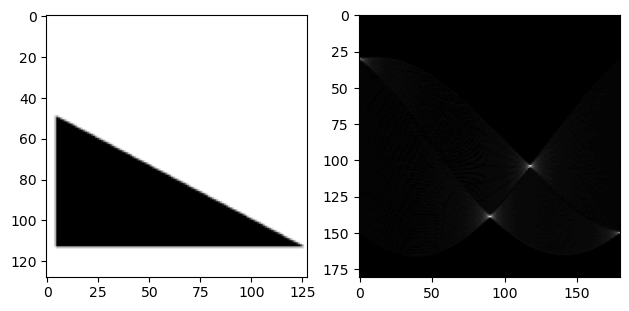

In [1519]:
testimage1 = np.load("../DD2423_Python_Labs_1_2/Images-npy/triangle128.npy")
smalltest1 = binsubsample(testimage1)
testimage2 = np.load("../DD2423_Python_Labs_1_2/Images-npy/houghtest256.npy")
smalltest2 = binsubsample(binsubsample(testimage2))

height, width = testimage1.shape
xc, yc = width/2, height/2
rhomax = np.sqrt(xc**2 + yc**2)

# target drho ≈ 1 pixel
nrho = int(2 * rhomax / 1.0)   # number of rho bins

# target dtheta ≈ 1 degree
ntheta = 180   # for 1 degree steps over [-90, 90] or [0, 180]
# ntheta = 360

print("nrho:", nrho)

plt.subplot(1, 2, 1)
showgrey(testimage1, display=False)

dxtest = convolve2d(testimage1, dxmask, 'same')
dytest = convolve2d(testimage1, dymask, 'same')
# test_magnitude = np.sqrt(dxtest**2 + dytest**2)

plt.subplot(1, 2, 2)
# theta goes from 0 degrees to 90 degrees
# If threshold is too high some edge points are skipped
# if threshold too low, false peaks can appear   

linepar, acc = houghedgeline(pic=testimage1, nrho=nrho, ntheta=ntheta, gradmagnthreshold=5, nlines=3, scale=2, verbose=2, use_gradient_dir=False)
showgrey(acc, display=False)

plt.tight_layout()
plt.show()


In [1520]:
print(linepar)

[(np.float64(60.339778661252055), np.float64(3.141592653589793)), (np.float64(49.27748590668919), np.float64(1.562020928321182)), (np.float64(14.079281687625482), np.float64(2.053443242849194))]


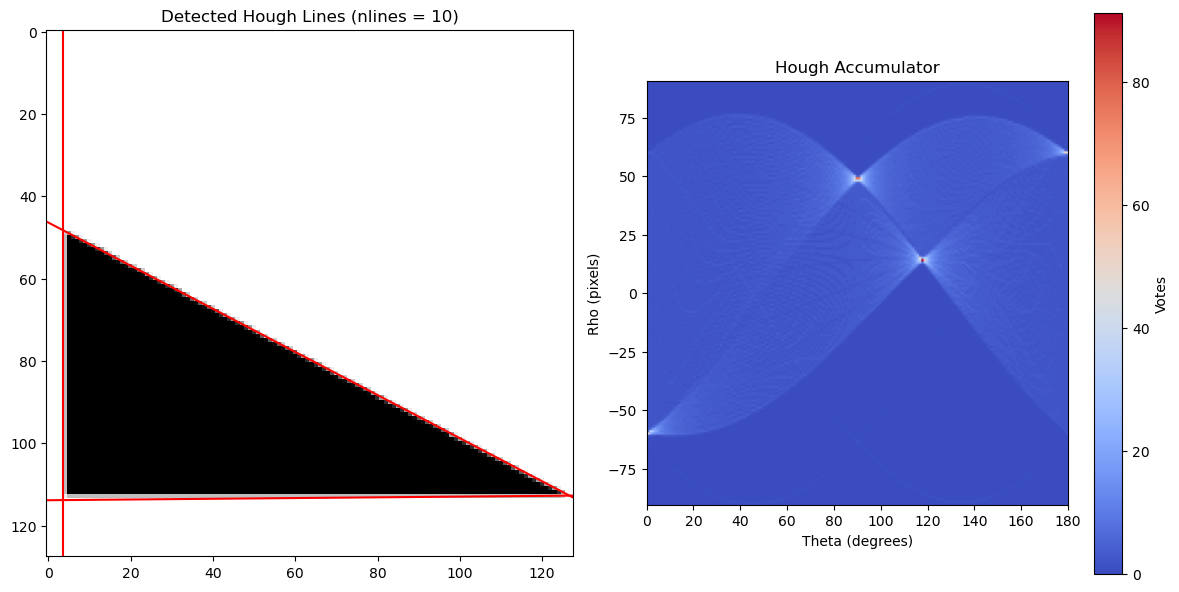

In [1521]:
thetas = np.linspace(0, np.pi, ntheta)
rhomax = np.sqrt((width/2)**2 + (height/2)**2)
rhos = np.linspace(-rhomax, rhomax, nrho)
draw_hough_lines(testimage1, acc, thetas, rhos, linepar, nlines=nlines, color='r', linewidth=1)

Explanation:
The Hough accumulator acc is a 2D array of size (nrho, ntheta)
y-axis (rows) -> rho bins (distance from the origin to the line, negative to positive)
x-axis (columns) -> theta bins

Each element acc[rho_idx, theta_idx] counts how many edge points voted for a line with that (rho, theta).

A triangle image has three straight edges. Each edge produces a set of edge points. Every edge point “votes” for all lines that pass through it (theta and rho values).

The votes accumulate in the Hough space.
Local maxima in acc correspond to lines that have many points along them, i.e., the actual edges of the triangle. 
Bright spots = peaks = strong evidence of a line
Dark areas = few or no points support that line


[[0.0625 0.125  0.0625]
 [0.125  0.25   0.125 ]
 [0.0625 0.125  0.0625]]
[[0.0625 0.125  0.0625]
 [0.125  0.25   0.125 ]
 [0.0625 0.125  0.0625]]
[[0.0625 0.125  0.0625]
 [0.125  0.25   0.125 ]
 [0.0625 0.125  0.0625]]
nrho: 363
nrho=363, ntheta=180, drho=1.00, rhomax=181.02
(363, 180) (363, 180) (363, 180)
Extracting 10 strongest lines.


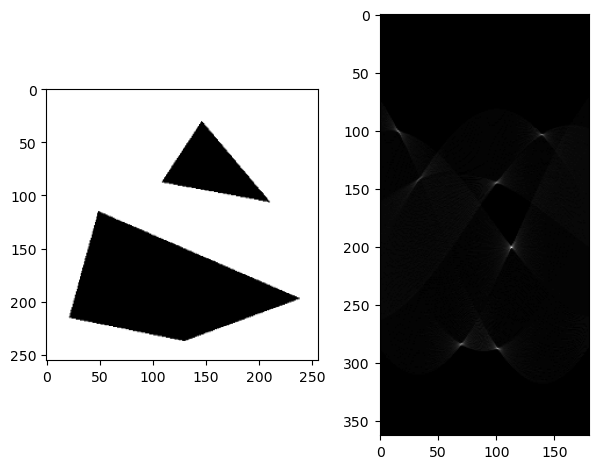

In [1522]:
smalltest1 = binsubsample(testimage1)
testimage2 = np.load("../DD2423_Python_Labs_1_2/Images-npy/houghtest256.npy")
smalltest2 = binsubsample(binsubsample(testimage2))

height, width = testimage2.shape
rhomax = np.sqrt((width/2)**2 + (height/2)**2)

# target drho ≈ 1 pixel
nrho = int(np.ceil(2 * rhomax / 1.0))   # number of rho bins
print("nrho:", nrho)

# target dtheta ≈ 1 degree
ntheta = 180   # for 1 degree steps over [0, 180]
# ntheta = ntheta * 2
nlines = 10
# nrho = nrho * 2
gradmagnthreshold=2
scale = 1

plt.subplot(1, 2, 1)
showgrey(testimage2, display=False)

dxtest = convolve2d(testimage2, dxmask, 'same')
dytest = convolve2d(testimage2, dymask, 'same')
test_magnitude = np.sqrt(dxtest**2 + dytest**2)

plt.subplot(1, 2, 2)
# theta goes from -90 degrees to 90 degrees
linepar, acc = houghedgeline(pic=testimage2, scale=scale, gradmagnthreshold=gradmagnthreshold, nrho=nrho, ntheta=ntheta, nlines=nlines, verbose=2)
showgrey(acc, display=False)

plt.tight_layout()
plt.show()


The strongest peaks in acc correspond to the lines with the most edge points supporting them.
Strongest peak -> longest line / most votes
Second peak -> second strongest line etc

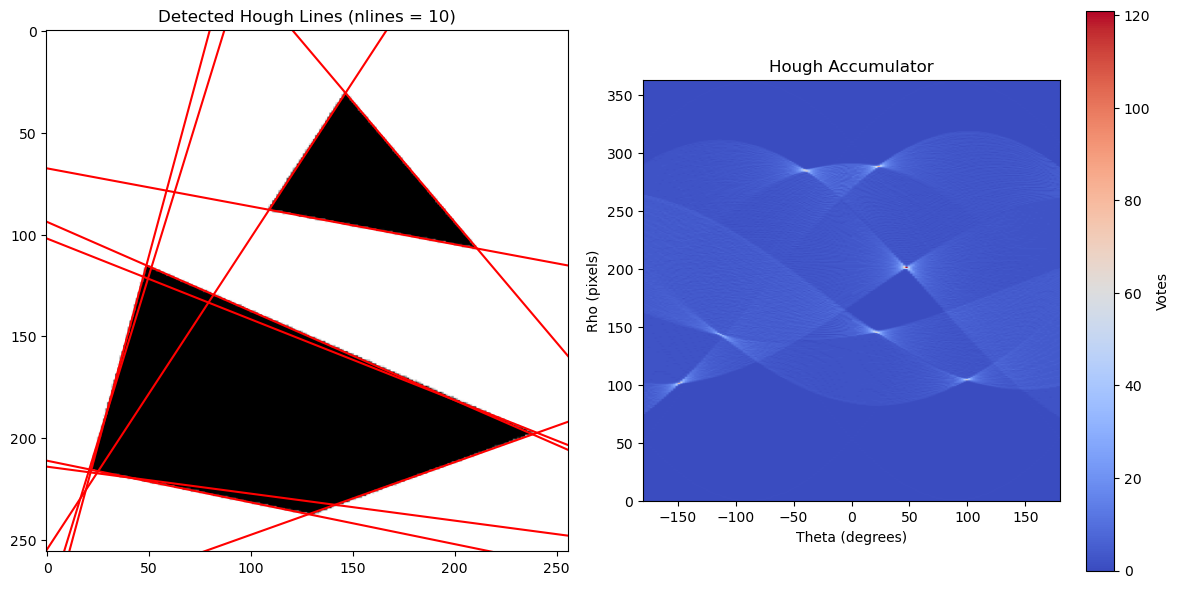

In [1523]:
# thetas = np.linspace(-np.pi/2, np.pi/2, ntheta)
thetas = np.linspace(-np.pi, np.pi, ntheta)
rhos = np.linspace(0, nrho, nrho) 
draw_hough_lines(testimage2, acc, thetas, rhos, linepar, nlines=nlines, color='r', linewidth=1)

nrho=181, ntheta=90, drho=2.01, rhomax=181.02
(181, 90) (181, 90) (181, 90)
Extracting 10 strongest lines.
nrho: 181, ntheta: 90, Time: 0.12012219429016113
nrho=181, ntheta=180, drho=2.01, rhomax=181.02
(181, 180) (181, 180) (181, 180)
Extracting 10 strongest lines.
nrho: 181, ntheta: 180, Time: 0.10850095748901367
nrho=181, ntheta=270, drho=2.01, rhomax=181.02
(181, 270) (181, 270) (181, 270)
Extracting 10 strongest lines.
nrho: 181, ntheta: 270, Time: 0.10497307777404785
nrho=362, ntheta=90, drho=1.00, rhomax=181.02
(362, 90) (362, 90) (362, 90)
Extracting 10 strongest lines.
nrho: 362, ntheta: 90, Time: 0.07013106346130371
nrho=362, ntheta=180, drho=1.00, rhomax=181.02
(362, 180) (362, 180) (362, 180)
Extracting 10 strongest lines.
nrho: 362, ntheta: 180, Time: 0.07177901268005371
nrho=362, ntheta=270, drho=1.00, rhomax=181.02
(362, 270) (362, 270) (362, 270)
Extracting 10 strongest lines.
nrho: 362, ntheta: 270, Time: 0.0763547420501709
nrho=543, ntheta=90, drho=0.67, rhomax=181.02

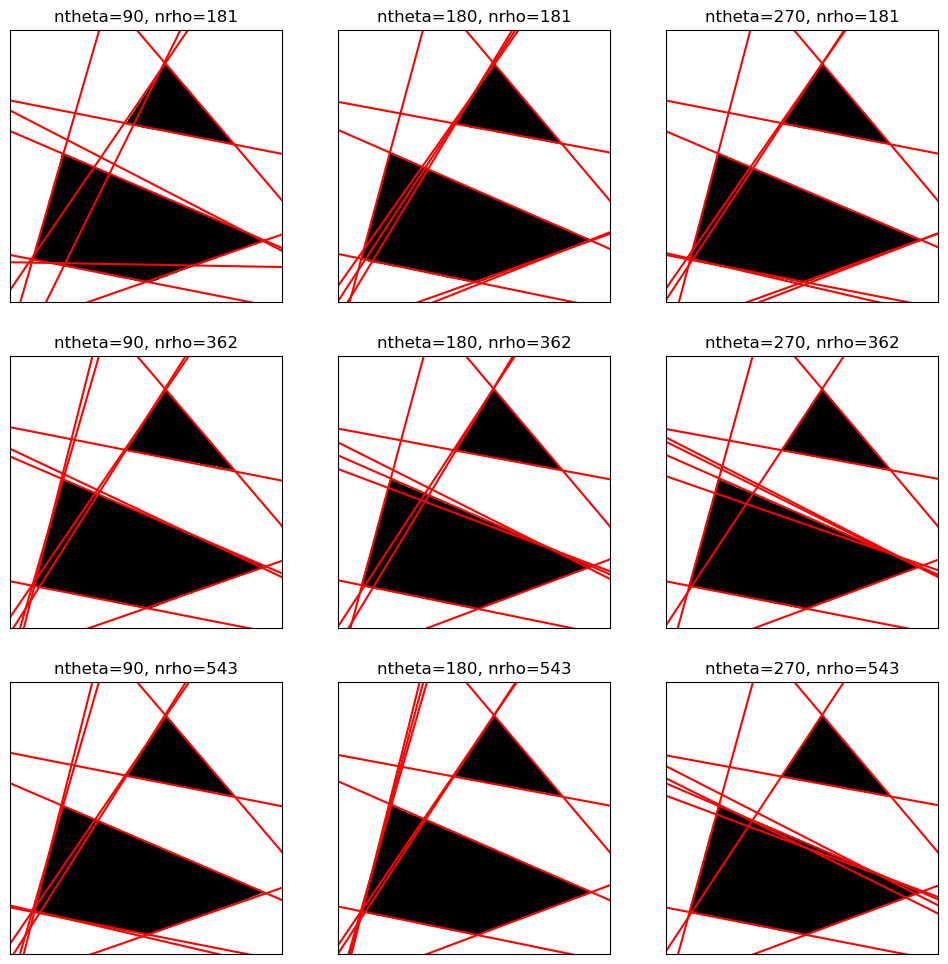

In [1558]:
img = testimage2
sigma = 2
gradmagnthreshold = 1

H, W = img.shape
R = np.sqrt((W/2)**2 + (H/2)**2)

nlines = 10

nrho, ntheta = int(2*R), 180

i = 1
scale = [0.5, 1, 1.5]    # increasing number of cells in the accumulator
plt.figure(figsize=(12, 12))
for nr in scale:
    for nt in scale:    
        plt.subplot(3,3,i)
        start = time.time()
        nrho_scaled = int(nr*nrho)
        ntheta_scaled = int(nt*ntheta)
        _, _ = houghedgeline(img, nrho_scaled, ntheta_scaled, gradmagnthreshold, nlines, scale=sigma, verbose=2, smooth=True, accumulator='one', use_gradient_dir=False, plot=True)
        # draw_hough_lines(img, acc, ntheta_scaled, nrho_scaled, linepar, nlines=nlines, color='r', linewidth=1)
        # plot_edges(img=img, linepar=linepar, acc=acc, ntheta=int(ntheta_scaled), nrho=int(nrho_scaled), verbose=3, plotlog=False)
        # _, _  = houghline(img, sigma, gradmagnthreshold, int(nr*nrho), int(nt*ntheta), nlines, smooth=True, verbose=2)
        end = time.time()
        plt.title(f"ntheta={ntheta_scaled}, nrho={nrho_scaled}")
        # plt.title(r'$n\theta$ = ' + str(ntheta) + r', $n\rho$ = ' +str(nrho))
        print(f"nrho: {nrho_scaled}, ntheta: {ntheta_scaled}, Time: {end - start}")
        i += 1

Higher nrho -> smaller rho bins -> cleaner edges 

Each accumulator bin covers a smaller range of distances. Peaks correspond more accurately to the exact rho of the line.
Cost: larger accumulator matrix → more memory, slower computation.

Up to ntheta = 180, increasing ntheta yields more accurate lines. After that, votes get too spread out over many bins and no longer accumulate. 
Many votes fall between bins or are distributed across adjacent bins -> accumulator becomes noisy.

ntheta ≈ 180 was a good choice for ntheta, and nrho = 543 provided the best results.

nrho=363, ntheta=180, drho=1.00, rhomax=181.02
(363, 180) (363, 180) (363, 180)
Extracting 10 strongest lines.


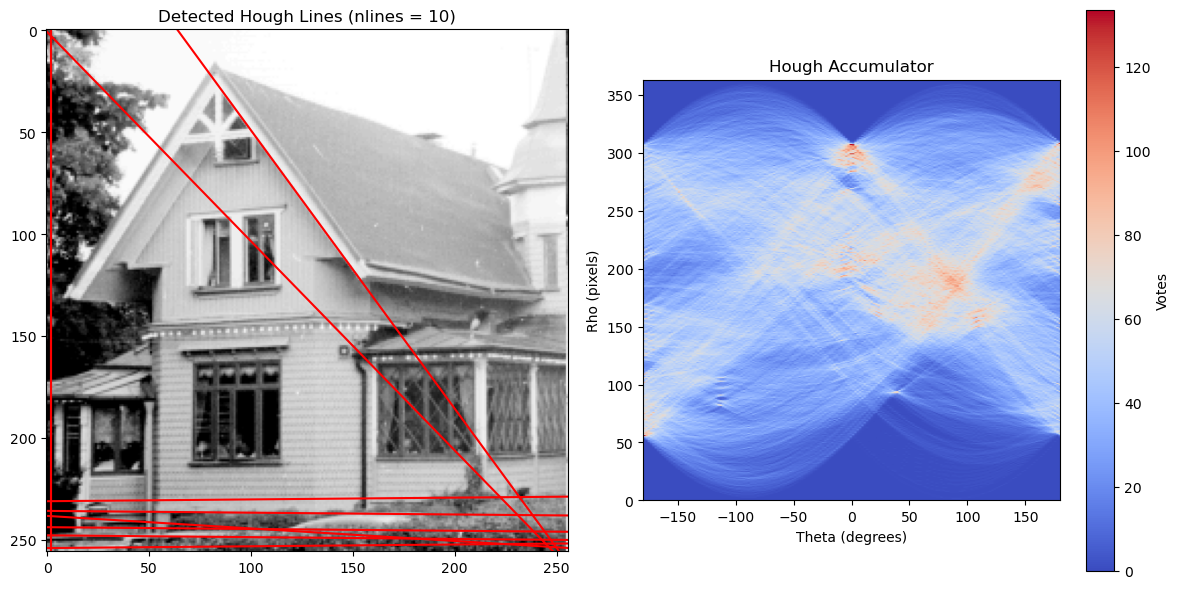

nrho=363, ntheta=180, drho=1.00, rhomax=181.02
(363, 180) (363, 180) (363, 180)
Extracting 10 strongest lines.


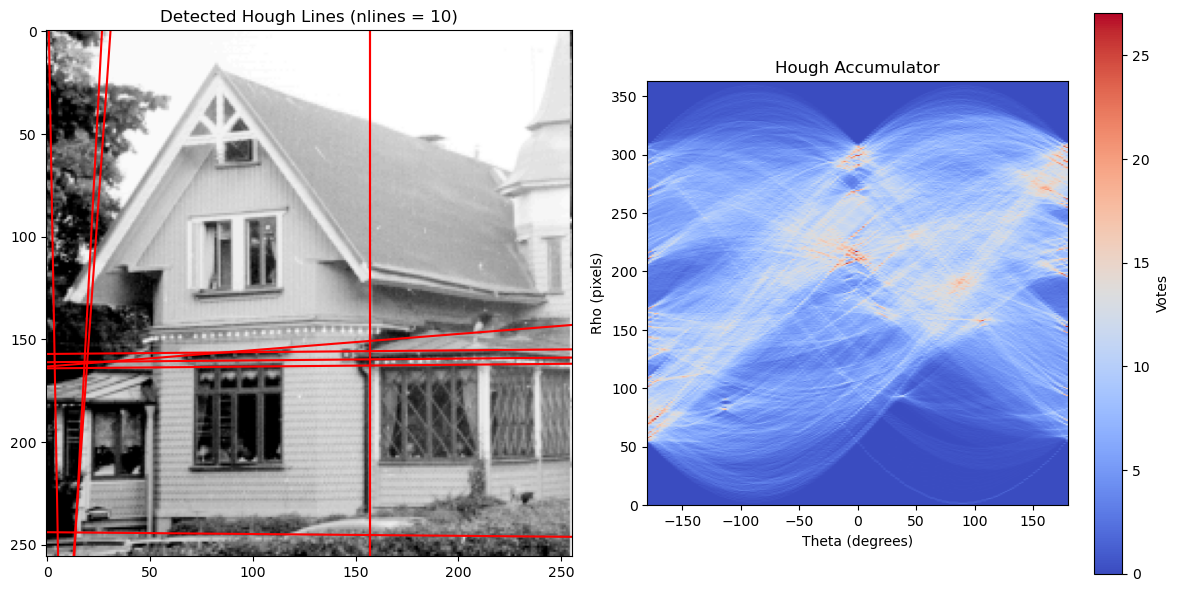

nrho=363, ntheta=180, drho=1.00, rhomax=181.02
(363, 180) (363, 180) (363, 180)
Extracting 10 strongest lines.


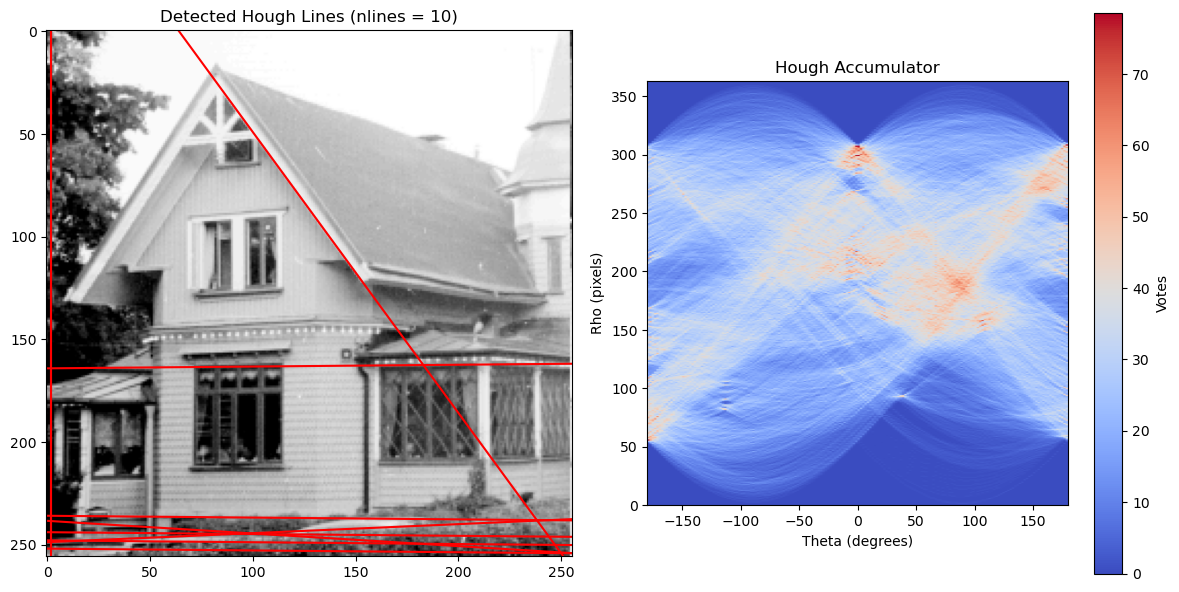

In [1524]:
height, width = house.shape
rhomax = np.sqrt((width/2)**2 + (height/2)**2)
scale = 1
gradmagnthreshold=3

# target drho ≈ 1 pixel
nrho = int(np.ceil(2 * rhomax / 1.0))

linepar, acc = houghedgeline(pic=house, scale=scale, gradmagnthreshold=gradmagnthreshold, nrho=nrho, ntheta=ntheta, nlines=nlines, verbose=2, accumulator='one')
draw_hough_lines(house, acc, thetas, rhos, linepar, nlines=nlines, color='r', linewidth=1)

linepar, acc = houghedgeline(pic=house, scale=scale, gradmagnthreshold=gradmagnthreshold, nrho=nrho, ntheta=ntheta, nlines=nlines, verbose=2,  accumulator='linear')
draw_hough_lines(house, acc, thetas, rhos, linepar, nlines=nlines, color='r', linewidth=1)

linepar, acc = houghedgeline(pic=house, scale=scale, gradmagnthreshold=gradmagnthreshold, nrho=nrho, ntheta=ntheta, nlines=nlines, verbose=2,  accumulator='sigmoid')
draw_hough_lines(house, acc, thetas, rhos, linepar, nlines=nlines, color='r', linewidth=1)

If you use the accumulator that votes 1 per edge point, you ignore the extra information in gradient strength and treat all edges equally, which loses some information about "important" edges.

Using the normalized gradient magnitude (linear) is good at capturing horizontal and vertical lines, but not so much the inclined
ones. It could be interpreted as: if you use a linear weighting, the accumulator becomes dominated by a few very strong edges, so weaker lines (even if consistent across space and angle) will be drowned out.

Sigmoid was a pretty good choice of an accumulator function, as it found both inclined and horizontal/vertical lines. This makes sense, bevause a sigmoid transforms magnitudes non-linearly. It "boosts" mid-range magnitudes (making many edges more influential) and saturates very large magnitudes so they don’t completely dominate. The result is both moderately strong lines that are inclined/diagonal and the very strong axis-aligned lines represented.